# K-Means Clustering

![Grafik Data](../img/knime.png)

# Dokumentasi Workflow (KNIME)

Workflow di atas merupakan rancangan proses klasterisasi menggunakan algoritma K-Means yang membandingkan dua eksperimen utama, yaitu **tanpa reduksi dimensi** dan **dengan reduksi dimensi menggunakan PCA**. Masing-masing eksperimen diuji dengan jumlah klaster (`k`) sebanyak **3 dan 5**.

## Penjelasan Node yang Digunakan

Berikut adalah penjelasan fungsi untuk setiap node yang digunakan dalam workflow:

### 1. PostgreSQL Connector

Berfungsi untuk membangun koneksi dari KNIME ke server database PostgreSQL menggunakan kredensial yang sesuai, seperti **host, port, database, username, dan password**.

### 2. DB Table Selector

Berfungsi untuk menyeleksi atau memilih tabel spesifik beserta kolom-kolom yang diperlukan dari database. Pada workflow ini, tabel yang dipilih berisi data mentah polutan.

### 3. DB Reader

Berfungsi untuk mengeksekusi query dari **DB Table Selector** dan mengambil atau mengimpor data dari database ke dalam environment KNIME agar dapat diproses pada node-node selanjutnya.

### 4. Column Filter

Berfungsi untuk menyeleksi fitur-fitur yang akan digunakan dalam proses pemodelan.

Pada kasus ini, node **Column Filter** digunakan untuk menghilangkan kolom `id` karena kolom tersebut tidak memiliki nilai analitik yang diperlukan dalam proses klasterisasi.

### 5. PCA (Principal Component Analysis)

**PCA (Principal Component Analysis)** merupakan teknik reduksi dimensi yang digunakan untuk menyederhanakan kompleksitas data berdimensi tinggi dengan tetap mempertahankan informasi penting sebanyak mungkin.

PCA bekerja dengan mentransformasikan fitur-fitur asli yang mungkin saling berkorelasi menjadi sekumpulan variabel baru yang disebut **Principal Components (Komponen Utama)**.

Pada eksperimen ini, PCA digunakan untuk mengatasi masalah **curse of dimensionality (kutukan dimensi)** akibat banyaknya jumlah fitur. Berdasarkan workflow, PCA berhasil mereduksi dimensi dari **68 fitur awal menjadi 37 komponen utama**.

Penerapan PCA dalam alur K-Means memiliki beberapa manfaat, yaitu:

- **Meningkatkan performa K-Means**  
  K-Means mengelompokkan data berdasarkan jarak, seperti jarak Euclidean. Pada dimensi yang terlalu tinggi, perbedaan jarak antar titik data dapat menjadi kurang jelas sehingga proses klasterisasi dapat menjadi kurang efektif.

- **Meningkatkan efisiensi komputasi**  
  Jumlah dimensi yang lebih sedikit dapat mengurangi jumlah perhitungan yang diperlukan sehingga proses dapat berjalan lebih efisien.

- **Mengurangi noise**  
  PCA dapat membantu mempertahankan informasi utama dari data dan mengurangi pengaruh fitur yang kurang relevan terhadap proses klasterisasi.

### 6. K-Means

**K-Means** merupakan algoritma inti yang bertugas mengelompokkan data ke dalam sejumlah klaster berdasarkan kemiripan karakteristik data.

Pada workflow ini, K-Means dijalankan dalam **4 skenario**, yaitu:

1. Klastering dengan **3 klaster** menggunakan data asli tanpa PCA.
2. Klastering dengan **5 klaster** menggunakan data asli tanpa PCA.
3. Klastering dengan **3 klaster** menggunakan **37 komponen hasil PCA**.
4. Klastering dengan **5 klaster** menggunakan **37 komponen hasil PCA**.

Dengan demikian, hasil dari keempat skenario tersebut dapat dibandingkan untuk melihat perbedaan hasil klasterisasi antara data asli dan data yang telah direduksi menggunakan PCA.

### 7. Silhouette Coefficient

**Silhouette Coefficient** merupakan metrik evaluasi yang digunakan untuk mengukur seberapa baik setiap titik data dikelompokkan ke dalam klasternya sendiri dibandingkan dengan klaster lainnya.

Nilai Silhouette Coefficient berada pada rentang **-1 hingga 1**. Nilai yang semakin mendekati **1** menunjukkan bahwa data cenderung memiliki pemisahan klaster yang lebih baik.

### 8. Table View Node

**Table View Node** digunakan untuk menampilkan nilai **Silhouette Coefficient** untuk masing-masing data dalam bentuk tabel interaktif.

Node ini juga menampilkan ringkasan nilai, termasuk nilai **Mean** yang menunjukkan rata-rata Silhouette Coefficient dari seluruh data.

Berdasarkan hasil pada workflow, nilai rata-rata (*Mean*) tertinggi yang diperoleh adalah **0.946 pada pembagian 3 klaster**.

### 9. Scatter Plot Node

**Scatter Plot Node** digunakan untuk membuat grafik pencar yang memperlihatkan persebaran titik-titik data berdasarkan klaster yang terbentuk.

Visualisasi ini membantu melihat bagaimana data tersebar dan seberapa jelas pemisahan antar klaster secara visual.

Dengan menggunakan scatter plot, hasil klasterisasi dari K-Means dapat diamati secara lebih mudah untuk melihat pola dan separasi antar kelompok data.

# Hasil Evaluasi dan Visualisasi per Skenario

Pada bagian ini, evaluasi pembentukan klaster yang diukur menggunakan **rata-rata Silhouette Coefficient** dan visualisasinya menggunakan **Scatter Plot** dibagi ke dalam empat eksperimen yang berbeda.

Keempat skenario tersebut terdiri dari:

1. Klastering **3 kelas tanpa PCA**.
2. Klastering **5 kelas tanpa PCA**.
3. Klastering **3 kelas dengan PCA** menggunakan 37 komponen utama.
4. Klastering **5 kelas dengan PCA** menggunakan 37 komponen utama.

Setiap skenario akan menampilkan hasil nilai **Silhouette Coefficient** dan **Scatter Plot** untuk melihat kualitas serta persebaran klaster yang terbentuk.

## 1. Klastering 3 Kelas (Tanpa PCA)

### Tabel Silhouette Coefficient untuk k=3 tanpa PCA

![Grafik Data](../img/sc3npca.png)

### Visualisasi Scatter Plot untuk k=3 tanpa PCA

![Grafik Data](../img/sp3npca.png)

### Implementasi Code Python

Inertia: 660.2141

Jumlah data per cluster:
cluster_label
cluster_0     1
cluster_1    35
cluster_2     1
Name: count, dtype: int64


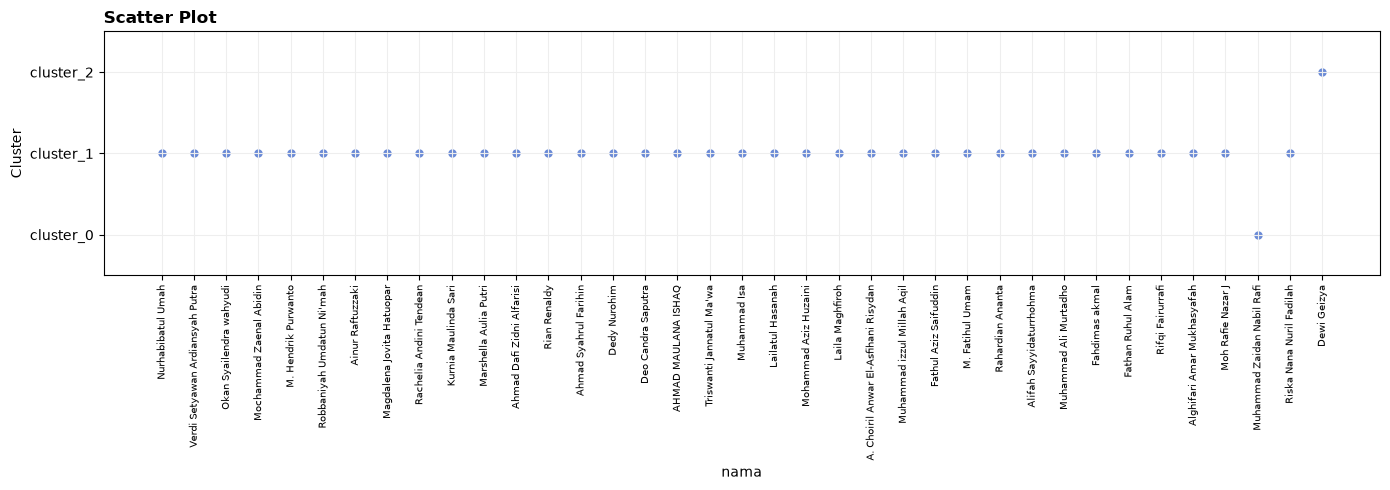

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


CSV_PATH = "ekstraksi_fitur_co.csv"                      
KOLOM_NAMA = "nama"                         
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()       

K = 3                                       
GUNAKAN_SCALING = True                    

# 1. Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()

# 2. Standarisasi (opsional)
if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# 3. K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# 4. Hasil 
print(f"Inertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# 5. Scatter plot: nama (sumbu X) vs cluster (sumbu Y)
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()

## 2. Klastering 5 Kelas (Tanpa PCA)

### Tabel Silhouette Coefficient untuk k=5 tanpa PCA

![Grafik Data](../img/sc5npca.png)

### Visualisasi Scatter Plot untuk k=5 tanpa PCA

![Grafik Data](../img/sp5npca.png)

### Implementasi Code Python

Inertia: 413.8895

Jumlah data per cluster:
cluster_label
cluster_0    12
cluster_1     1
cluster_2     2
cluster_3     1
cluster_4    21
Name: count, dtype: int64


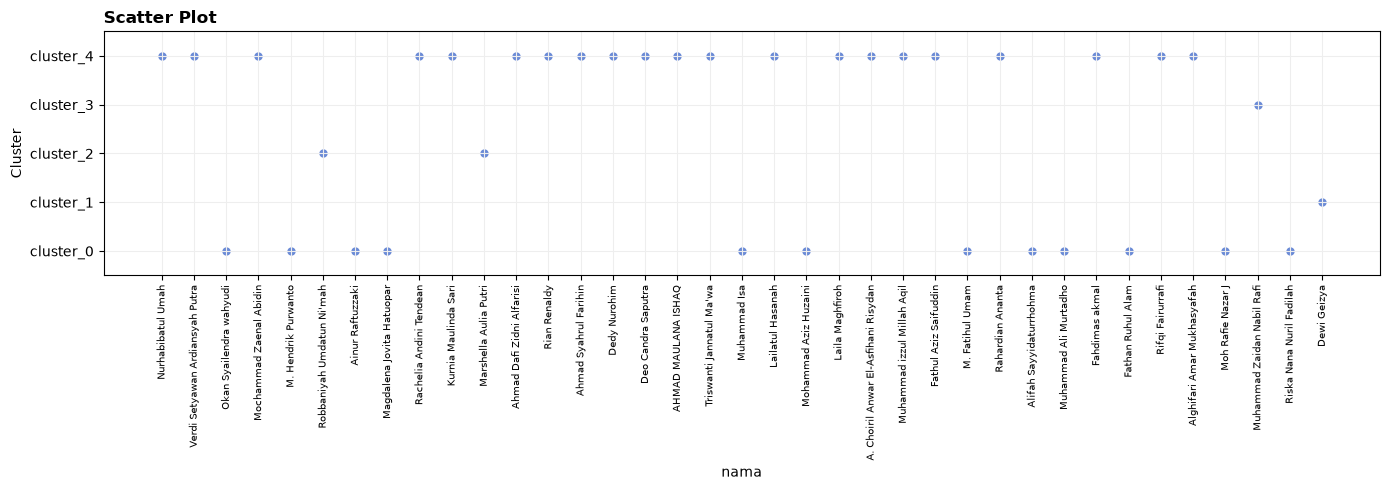

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


CSV_PATH = "ekstraksi_fitur_co.csv"                      
KOLOM_NAMA = "nama"                         
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()       

K = 5                                      
GUNAKAN_SCALING = True                    

# 1. Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()

# 2. Standarisasi
if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# 3. K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# 4. Hasil 
print(f"Inertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())
x
# 5. Scatter plot: nama (sumbu X) vs cluster (sumbu Y)
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()

## 3. Klastering 3 Kelas (Dengan PCA)

### Tabel Silhouette Coefficient untuk k=3 dengan PCA

![Grafik Data](../img/sc3npca.png)

### Visualisasi Scatter Plot untuk k=3 dengan PCA

![Grafik Data](../img/sp3npca.png)

### Implementasi Code Python

PCA: 68 fitur -> 37 dimensi

Inertia: 660.2141

Jumlah data per cluster:
cluster_label
cluster_0     1
cluster_1    35
cluster_2     1
Name: count, dtype: int64


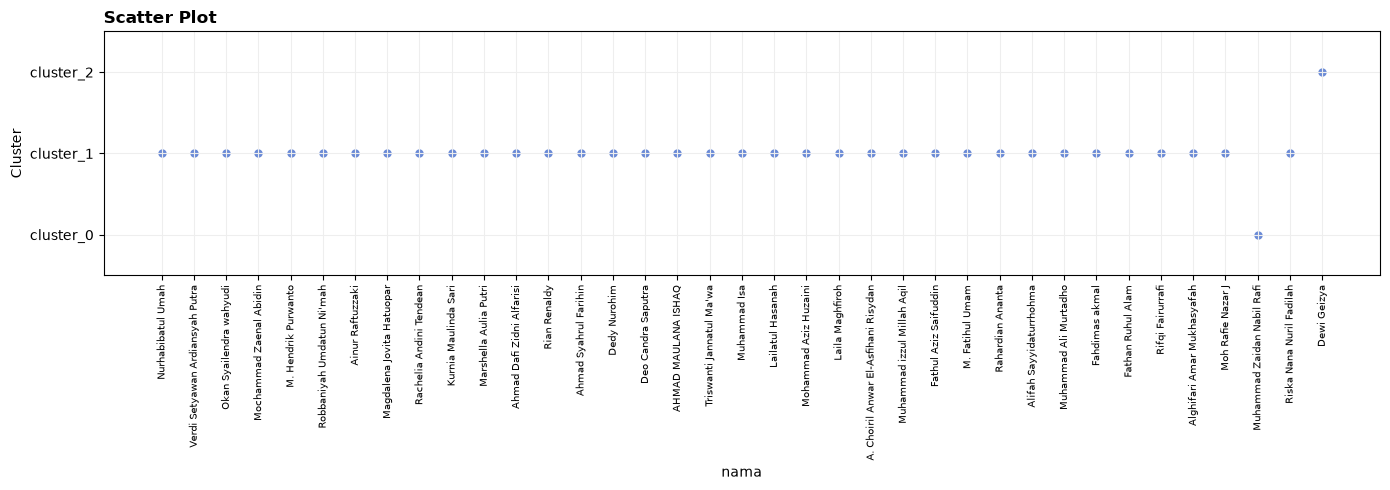

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "ekstraksi_fitur_co.csv"               
KOLOM_NAMA = "nama"                               
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 3
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()

## 4. Klastering 5 Kelas (Dengan PCA)

### Tabel Silhouette Coefficient untuk k=5 dengan PCA

![Grafik Data](../img/sc5npca.png)

### Visualisasi Scatter Plot untuk k=5 dengan PCA

![Grafik Data](../img/sp5npca.png)

### Implementasi Code Python

PCA: 68 fitur -> 37 dimensi

Inertia: 413.8895

Jumlah data per cluster:
cluster_label
cluster_0    12
cluster_1     1
cluster_2     2
cluster_3     1
cluster_4    21
Name: count, dtype: int64


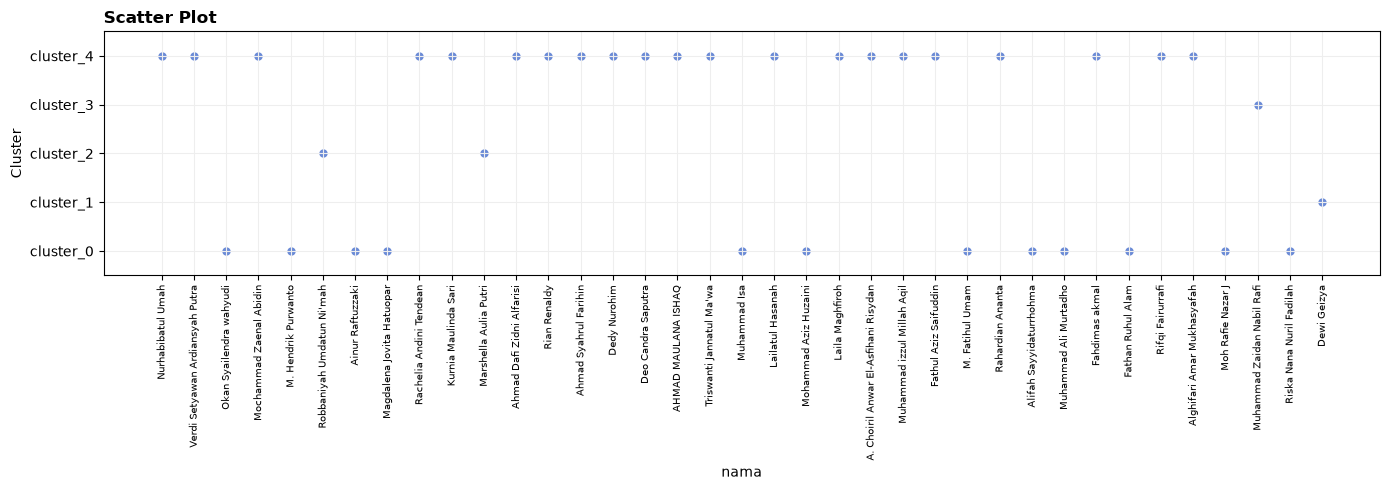

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "ekstraksi_fitur_co.csv"               
KOLOM_NAMA = "nama"                               
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 5
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()

# Kesimpulan

Berdasarkan rancangan eksperimen klasterisasi menggunakan algoritma **K-Means**, dapat ditarik beberapa kesimpulan utama:

### 1. Jumlah Klaster Optimal (k=3)

Pembagian data menjadi **3 klaster (k=3)** menghasilkan performa yang lebih baik dibandingkan dengan **5 klaster (k=5)**. Hal ini ditunjukkan oleh rata-rata nilai **Silhouette Coefficient sebesar 0.946** pada k=3.

Nilai tersebut mendekati 1, yang menunjukkan bahwa data dalam setiap klaster memiliki tingkat kemiripan yang tinggi dan pemisahan antar klaster yang jelas.

Sementara itu, pada **k=5**, nilai rata-rata Silhouette Coefficient turun menjadi **0.384**. Penurunan tersebut menunjukkan bahwa ketika jumlah klaster ditambah menjadi 5, pemisahan antar beberapa klaster menjadi kurang jelas dan terdapat kemungkinan data yang memiliki karakteristik saling berdekatan.

### 2. Efektivitas PCA

Penggunaan **PCA (Principal Component Analysis)** berhasil mereduksi dimensi data secara signifikan, yaitu dari **68 fitur awal menjadi 37 komponen utama**.

Reduksi dimensi ini dapat mengurangi kompleksitas data dan jumlah perhitungan yang dilakukan dalam proses klasterisasi. Selain itu, PCA membantu mengurangi permasalahan **curse of dimensionality** pada data dengan jumlah fitur yang cukup banyak.

Berdasarkan hasil eksperimen, penggunaan PCA tetap dapat mempertahankan informasi penting yang diperlukan oleh algoritma K-Means dalam membentuk klaster. Dengan demikian, PCA dapat digunakan sebagai tahap reduksi dimensi sebelum proses klasterisasi tanpa menghilangkan seluruh informasi penting dari data.